# Practice 3: Customer Clustering - Bước 6.1: KMeans & KMedoids Clustering

---

## 1. Import các thư viện và tải dữ liệu đặc trưng đầy đủ

Chúng ta tải dữ liệu đã tiền xử lý từ `../data/processed_features/`.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
import os

%matplotlib inline

# Load dữ liệu 22 chiều đã xử lý đặc trưng
X_train = pd.read_csv('../data/processed_features/X_train.csv').values
X_val = pd.read_csv('../data/processed_features/X_val.values' if os.path.exists('../data/processed_features/X_val.values') else '../data/processed_features/X_val.csv').values

print(f'Kích thước dữ liệu huấn luyện: {X_train.shape}')
print(f'Kích thước dữ liệu xác thực:  {X_val.shape}')

Kích thước dữ liệu huấn luyện: (6455, 26)
Kích thước dữ liệu xác thực:  (1613, 26)


## 2. Hàm tính điểm Silhouette Score và Giảm chiều PCA từ Scratch

Để đánh giá chất lượng phân cụm và vẽ ranh giới cụm trong không gian 2D.

In [28]:
def custom_silhouette_score(X, labels):
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]
    n_clusters = len(unique_labels)
    
    if n_clusters <= 1 or n_clusters >= n_samples:
        return 0.0
        
    sum_squares = np.sum(X**2, axis=1, keepdims=True)
    dist_matrix = np.sqrt(np.maximum(sum_squares + sum_squares.T - 2 * np.dot(X, X.T), 0.0))
    
    s = np.zeros(n_samples)
    for i in range(n_samples):
        c_i = labels[i]
        if c_i == -1:
            continue
            
        same_cluster_idx = np.where(labels == c_i)[0]
        same_cluster_idx = same_cluster_idx[same_cluster_idx != i]
        if len(same_cluster_idx) > 0:
            a_i = np.mean(dist_matrix[i, same_cluster_idx])
        else:
            a_i = 0.0
            
        b_i = np.inf
        for c_j in unique_labels:
            if c_j == c_i:
                continue
            other_cluster_idx = np.where(labels == c_j)[0]
            mean_dist = np.mean(dist_matrix[i, other_cluster_idx])
            if mean_dist < b_i:
                b_i = mean_dist
                
        if max(a_i, b_i) > 0:
            s[i] = (b_i - a_i) / max(a_i, b_i)
        else:
            s[i] = 0.0
            
    valid_points = labels != -1
    return np.mean(s[valid_points])

class CustomPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        
    def fit(self, X):
        X_arr = np.array(X, dtype=float)
        self.mean_ = np.mean(X_arr, axis=0)
        X_centered = X_arr - self.mean_
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components_ = eigenvectors[:, sorted_indices][:, :self.n_components]
        return self
        
    def transform(self, X):
        X_arr = np.array(X, dtype=float)
        return np.dot(X_arr - self.mean_, self.components_)
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

pca_2d = CustomPCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)

## 3. Lập trình K-Means từ Scratch

In [29]:
class KMeansScratch:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.inertia_ = None
        
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        
        random_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_idx].copy()
        
        for it in range(self.max_iter):
            distances = np.zeros((n_samples, self.n_clusters))
            for k in range(self.n_clusters):
                distances[:, k] = np.sum((X - self.centroids[k])**2, axis=1)
            
            labels = np.argmin(distances, axis=1)
            new_centroids = np.zeros((self.n_clusters, n_features))
            
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                new_centroids[k] = np.mean(cluster_points, axis=0) if len(cluster_points) > 0 else self.centroids[k]
            
            diff = np.sum((new_centroids - self.centroids)**2)
            self.centroids = new_centroids
            if diff < self.tol:
                break
                
        self.inertia_ = np.sum(np.min(distances, axis=1))
        return self
        
    def predict(self, X):
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, self.n_clusters))
        for k in range(self.n_clusters):
            distances[:, k] = np.sum((X - self.centroids[k])**2, axis=1)
        return np.argmin(distances, axis=1)

## 4. Tìm số cụm K tối ưu cho K-Means

K = 2 | Inertia = 4455.63 | Silhouette Score = 0.2098
K = 3 | Inertia = 4005.29 | Silhouette Score = 0.1697
K = 4 | Inertia = 3669.22 | Silhouette Score = 0.1669
K = 5 | Inertia = 3514.01 | Silhouette Score = 0.1482
K = 6 | Inertia = 3284.29 | Silhouette Score = 0.1643


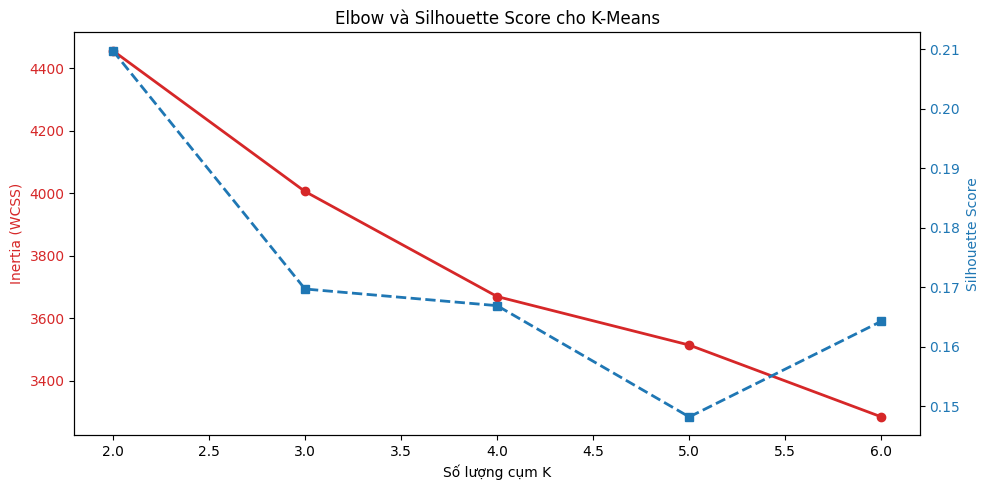

In [30]:
elbow_inertias = []
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    km = KMeansScratch(n_clusters=k, random_state=42).fit(X_val)
    labels = km.predict(X_val)
    elbow_inertias.append(km.inertia_)
    score = custom_silhouette_score(X_val, labels)
    silhouette_scores.append(score)
    print(f'K = {k} | Inertia = {km.inertia_:.2f} | Silhouette Score = {score:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Số lượng cụm K')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(k_range, elbow_inertias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow và Silhouette Score cho K-Means')
fig.tight_layout()
plt.show()

## 5. Huấn luyện K-Means với K tối ưu (K=3) & Trực quan hóa 2D

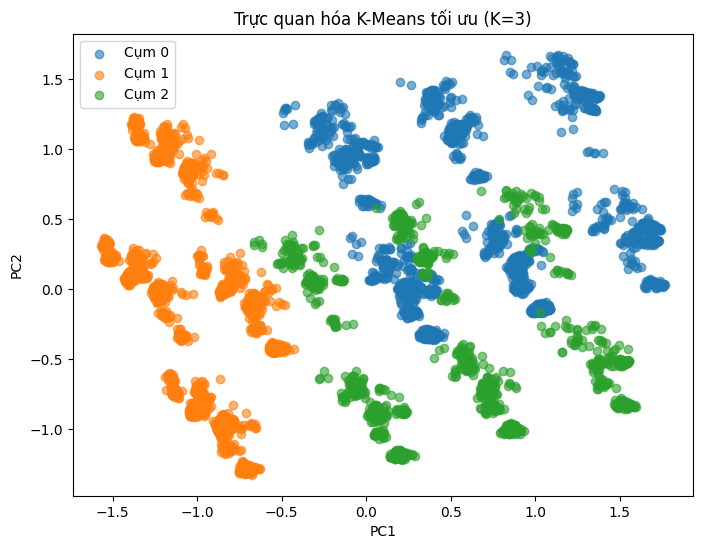

In [31]:
best_kmeans = KMeansScratch(n_clusters=3, random_state=42).fit(X_train)
train_labels_km = best_kmeans.predict(X_train)

plt.figure(figsize=(8, 6))
for k in range(3):
    idx = np.where(train_labels_km == k)[0]
    plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], label=f'Cụm {k}', alpha=0.6)
plt.title('Trực quan hóa K-Means tối ưu (K=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### 5.1. Phân tích khoảng cách chéo tâm cụm và bán kính phân tán cụm KMeans

Để phục vụ phân tích hình học cho DBSCAN ở bước sau, chúng ta tính toán khoảng cách chéo tâm cụm và bán kính phân tán cụm thực tế.

In [32]:
from scipy.spatial.distance import pdist, squareform

# 1. Khoảng cách chéo giữa các tâm cụm KMeans
centroid_dists = squareform(pdist(best_kmeans.centroids))
print('Ma trận khoảng cách Euclidean giữa các tâm cụm KMeans:')
print(centroid_dists)

# 2. Bán kính phân tán từ điểm tới tâm cụm tương ứng
distances_to_centroids = []
for k in range(best_kmeans.n_clusters):
    idx = np.where(train_labels_km == k)[0]
    if len(idx) > 0:
        diff = X_train[idx] - best_kmeans.centroids[k]
        dists = np.sqrt(np.sum(diff**2, axis=1))
        distances_to_centroids.extend(list(dists))

print('\nPhân phối khoảng cách từ các điểm tới tâm cụm tương ứng:')
print(f'  - Min: {np.min(distances_to_centroids):.4f}')
print(f'  - 25th percentile: {np.percentile(distances_to_centroids, 25):.4f}')
print(f'  - Median (Bán kính cụm trung bình): {np.median(distances_to_centroids):.4f}')
print(f'  - 90th percentile: {np.percentile(distances_to_centroids, 90):.4f}')
print(f'  - Max: {np.max(distances_to_centroids):.4f}')

Ma trận khoảng cách Euclidean giữa các tâm cụm KMeans:
[[0.         1.92150438 1.44221047]
 [1.92150438 0.         1.91532719]
 [1.44221047 1.91532719 0.        ]]

Phân phối khoảng cách từ các điểm tới tâm cụm tương ứng:
  - Min: 0.8440
  - 25th percentile: 1.3870
  - Median (Bán kính cụm trung bình): 1.5515
  - 90th percentile: 1.8742
  - Max: 2.2991


## 6. Lập trình K-Medoids từ Scratch

In [33]:
class KMedoidsScratch:
    def __init__(self, n_clusters=3, max_iter=30, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.medoids_idx = None
        self.medoids = None
        self.cost_ = None
        
    def _compute_manhattan_distance(self, X, medoids):
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, len(medoids)))
        for k, med in enumerate(medoids):
            distances[:, k] = np.sum(np.abs(X - med), axis=1)
        return distances
        
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        self.medoids_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.medoids = X[self.medoids_idx].copy()
        
        distances = self._compute_manhattan_distance(X, self.medoids)
        labels = np.argmin(distances, axis=1)
        current_cost = np.sum(np.min(distances, axis=1))
        
        for it in range(self.max_iter):
            best_medoids_idx = self.medoids_idx.copy()
            improved = False
            
            for k in range(self.n_clusters):
                cluster_member_indices = np.where(labels == k)[0]
                for candidate_idx in cluster_member_indices:
                    if candidate_idx in self.medoids_idx:
                        continue
                    
                    temp_medoids_idx = self.medoids_idx.copy()
                    temp_medoids_idx[k] = candidate_idx
                    temp_medoids = X[temp_medoids_idx]
                    
                    temp_distances = self._compute_manhattan_distance(X, temp_medoids)
                    temp_cost = np.sum(np.min(temp_distances, axis=1))
                    
                    if temp_cost < current_cost:
                        current_cost = temp_cost
                        best_medoids_idx = temp_medoids_idx.copy()
                        improved = True
            
            if improved:
                self.medoids_idx = best_medoids_idx.copy()
                self.medoids = X[self.medoids_idx].copy()
                distances = self._compute_manhattan_distance(X, self.medoids)
                labels = np.argmin(distances, axis=1)
            else:
                break
                
        self.cost_ = current_cost
        return self
        
    def predict(self, X):
        distances = self._compute_manhattan_distance(X, self.medoids)
        return np.argmin(distances, axis=1)

## 7. Huấn luyện K-Medoids với K tối ưu (K=3) & Trực quan hóa 2D

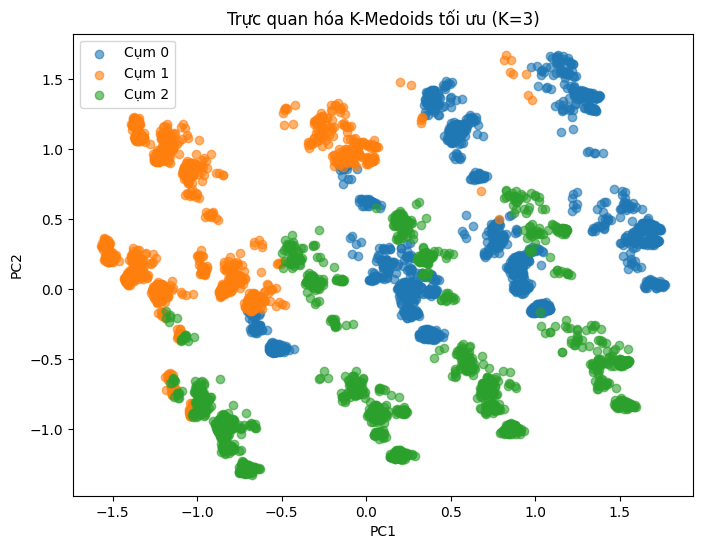

In [34]:
best_kmedoids = KMedoidsScratch(n_clusters=3, max_iter=15, random_state=42).fit(X_train)
train_labels_kmed = best_kmedoids.predict(X_train)

plt.figure(figsize=(8, 6))
for k in range(3):
    idx = np.where(train_labels_kmed == k)[0]
    plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], label=f'Cụm {k}', alpha=0.6)
plt.title('Trực quan hóa K-Medoids tối ưu (K=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## 8. Lưu trữ mô hình

In [35]:
os.makedirs('../models/', exist_ok=True)
with open('../models/kmeans_scratch.pkl', 'wb') as f:
    pickle.dump(best_kmeans, f)
with open('../models/kmedoids_scratch.pkl', 'wb') as f:
    pickle.dump(best_kmedoids, f)
np.save('../models/kmeans_centroids.npy', best_kmeans.centroids)
np.save('../models/kmeans_labels.npy', train_labels_km)
print('Đã lưu trữ KMeans và KMedoids thành công!')

Đã lưu trữ KMeans và KMedoids thành công!
